# Do Gann's magic 45-degree lines predict anything? 📐
### The "1x1 angle" — one of technical analysis's most mystical tools, measured in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Predictive_power%3F: Busted](https://img.shields.io/badge/Predictive_power%3F-Busted-8b949e?style=flat-square)

Back in the 1930s a trader named **W.D. Gann** claimed markets move in secret geometric harmony with *time*, and that the master tool was the **1x1 angle**: a straight line rising **one unit of price for every one unit of time** from an important low. Price *above* its 1x1 line, the legend says, is strong (the line is support); price *below* it has turned (the line is resistance). Disciples sell expensive courses on the "Gann fan" to this day.

It *sounds* scientific — angles! geometry! — so let's do the one thing the courses never do: draw the line by a fixed mechanical rule, follow it for 25 years, and check whether it actually beats just holding the thing.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Up front:** the answer is **no**. Every chart below is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gann_angles import data, strategy as st

HAVE_REAL = data.have_real("SPY")
print("real SPY cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'cost_bps': 2.0, 'asof': '2025-12-30', 'spy': (6509, '2000-01-03->2025-12-30', 'f3f23cb2e701', 0.0975, 73, 353, 0.58, 0.51, -2.38, -1.01, 0.351), 'dji': (6483, '2000-01-03->2025-12-30', '8236e62188eb', 6.4531, 76, 363, 0.28, 0.41, -3.88, -1.75, 0.903), 'aapl': (6509, '2000-01-03->2025-12-30', '4d41e1279ebe', 0.0437, 43, 235, 0.68, 0.79, -18.77, -2.87, 0.649), 'gld': (5288, '2004-11-18->2025-12-30', '639b729ba397', 0.0707, 71, 337, 0.59, 0.68, -3.09, -1.6, 0.348), 'latched_same': True, 'syn': [(0.0, 58, 315, -0.35, -0.38, 1.81, 0.65, 0.547), (0.0008, 59, 288, -0.01, -0.33, 5.22, 1.86, 0.059), (0.0015, 59, 192, 0.5, -0.3, 11.11, 3.93, 0.0), (0.003, 60, 140, 1.46, -0.21, 22.61, 6.96, 0.0)]}


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does being *above* the 1x1 line predict gains? | **No.** Buying only when price sits above its 1x1 angle **underperforms** simply holding the market — on the S&P, the Dow, Apple and gold alike. |
| Is the underperformance just bad luck? | **No** — and that's the point. A *random* on/off rule with the same shape does just as well, so the angle adds **nothing**. |
| Does "the trend holds until the angle breaks" help? | **No.** The latched version gives the **identical** result — the line is crossed so often there's no trend to ride. |
| Could it ever work? | **Yes — if markets actually respected fixed-slope lines.** Our planted test proves the detector *would* find that edge. Real markets just don't have it. |

> The geometry is real; the **prediction** is not. The 1x1 angle is a drawing, not a signal.

## 1 · The claim

> *"Markets are geometric. Draw a 1x1 line from a significant low — one point of price per one bar of time — and price will respect it. While price rides **above** the 1x1, the trend is strong and the line is support; the moment price falls **below** it, the trend has turned and the line becomes resistance. Trade with the angle."*

This is the heart of **Gann analysis** (W.D. Gann, *45 Years in Wall Street*, 1949). The 1x1 is the spine of the famous **Gann fan** (the 2x1, 1x2 and the rest are steeper/shallower lines off the same pivot). It's pure fixed geometry — which is exactly what makes it **testable**, unlike the hand-wavy parts of chart lore.

## 2 · So what?

If a *fixed-slope line* drawn from a past low really forecast the future, that would be extraordinary — it would mean tomorrow's return is encoded in a ruler-and-pencil angle off an old pivot, with **no reference to fundamentals, volatility, or anything else**. A working 1x1 would be free money: be long above the line, flat below it, and beat the market with a schoolchild's geometry set.

That's a strong claim, so it deserves a fair, mechanical test — and a clear way to be proven **wrong**: if timing the line does no better than a coin-flip on/off rule, the angle is decoration.

## 3 · How would we even know?

We make the subjective objective. For each market (S&P 500 `SPY`, the Dow `^DJI`, `AAPL`, gold `GLD`), daily, 2000→2025:

1. **Find the pivots.** A confirmed swing low = the lowest low in a centred ~1-month window (only knowable a couple of weeks later — no cheating).
2. **Draw the 1x1.** From the latest confirmed pivot low, a line rising a *fixed price step* per bar — calibrated to the chart's own scale so it sits at ~45°, the literal 1x1.
3. **Trade it.** Be **long** when the close is above the line, **flat** when below. Enter the day *after* the signal (one realistic lag), pay a small cost on each switch.
4. **The honest yardstick.** Compare to **buy-and-hold**, and to a **random** on/off rule of the same shape. *If the angle is real, it must beat both. If it doesn't, it's a mirage.*

## 4 · The teardown — let's actually look

**First, here's the 1x1 line on the S&P.** The orange line is the Gann 1x1 drawn from the latest confirmed pivot low; green shading marks where price sits *above* it (the supposed bullish regime).

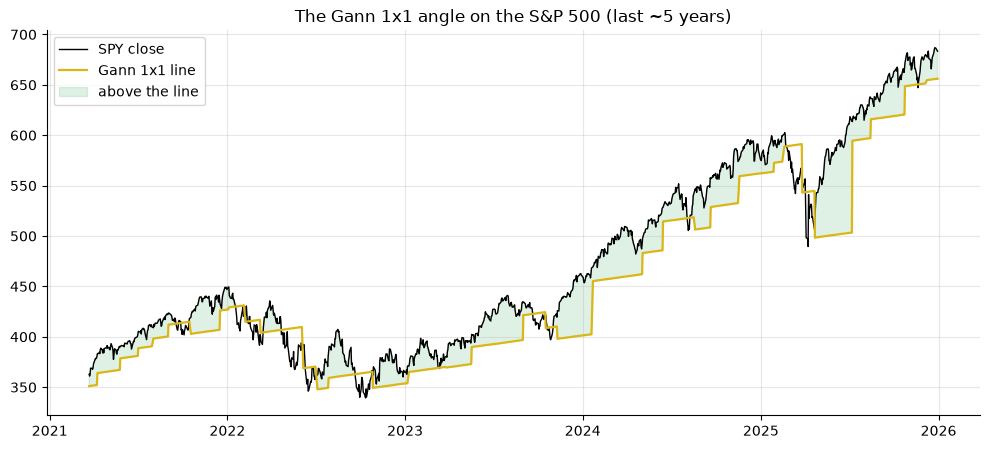

fraction of days above the line: 0.727


In [2]:
if HAVE_REAL:
    b = data.load_real('SPY', fetch=False)
    reg = st.gann_regime(b)
    sub = reg.iloc[-1200:]
    fig, ax = plt.subplots(figsize=(10.0, 4.6))
    ax.plot(sub.index, sub['close'], c='black', lw=1.0, label='SPY close')
    ax.plot(sub.index, sub['line'], c=AMBER, lw=1.6, label='Gann 1x1 line')
    ax.fill_between(sub.index, sub['close'], sub['line'],
                    where=(sub['regime']==1), color=GREEN, alpha=.15, label='above the line')
    ax.set_title('The Gann 1x1 angle on the S&P 500 (last ~5 years)')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
    print('fraction of days above the line:', round(float((reg["regime"]==1).mean()),3))
else:
    print('SPY cache missing; see docs/results.md for the frozen picture')

It *looks* meaningful — the line hugs price, sometimes acting like support. But looking convincing is exactly the trap. **Does trading it pay?**

**The verdict chart.** For each market, the Sharpe ratio of "long only when above the 1x1" vs simply **buying and holding**. If Gann were right, the green bars (the angle strategy) would tower over the grey (buy-and-hold).

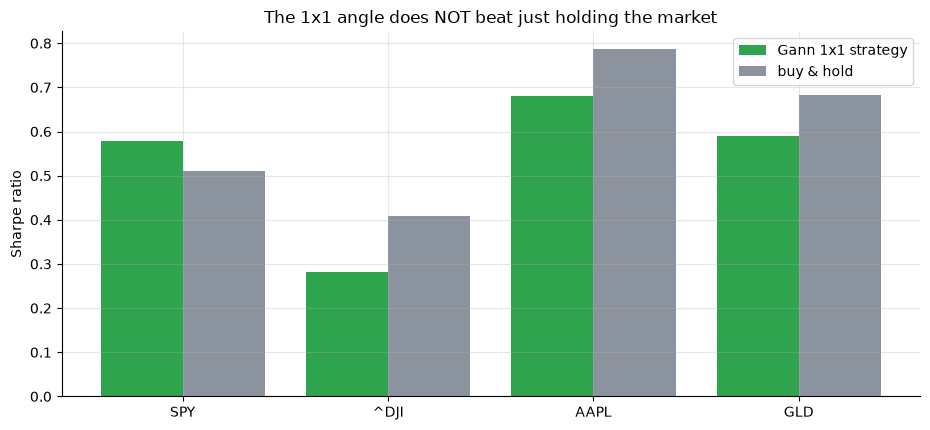

SPY   strategy Sharpe +0.58  vs buy-hold +0.51
^DJI  strategy Sharpe +0.28  vs buy-hold +0.41
AAPL  strategy Sharpe +0.68  vs buy-hold +0.79
GLD   strategy Sharpe +0.59  vs buy-hold +0.68


In [3]:
tks = ['SPY','^DJI','AAPL','GLD']
keys = ['spy','dji','aapl','gld']
if HAVE_REAL:
    sh_s, sh_b = [], []
    for tk in tks:
        bt = st.backtest(data.load_real(tk, fetch=False), cost_bps=R['cost_bps'])
        sh_s.append(bt['sharpe_strat']); sh_b.append(bt['sharpe_bh'])
else:
    sh_s = [R[k][6] for k in keys]; sh_b = [R[k][7] for k in keys]
x = np.arange(len(tks))
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(x-.2, sh_s, .4, color=GREEN, label='Gann 1x1 strategy')
ax.bar(x+.2, sh_b, .4, color=GREY, label='buy & hold')
ax.set_xticks(x); ax.set_xticklabels(tks); ax.set_ylabel('Sharpe ratio')
ax.set_title('The 1x1 angle does NOT beat just holding the market')
ax.legend(); plt.tight_layout(); plt.show()
for tk,a,c in zip(tks,sh_s,sh_b): print(f'{tk:5} strategy Sharpe {a:+.2f}  vs buy-hold {c:+.2f}')

The angle **loses** in every case. On the S&P the strategy's Sharpe is **0.58** vs **0.51** for buy-and-hold; on Apple it's a disaster (**0.68** vs **0.79**) because sitting out whenever price dips below a line means missing most of a great trend. Being clever with geometry **cost** money.

**But is it just bad luck?** Maybe the angle is fine and we got an unlucky stretch. To check, we replace the real 1x1 regime with a **random** on/off switch of the *same shape* (same fraction of time in the market, same average run length) and ask: does the real angle beat the dice? Here's where the real angle's edge over the market lands inside the cloud of random rules — for the S&P.

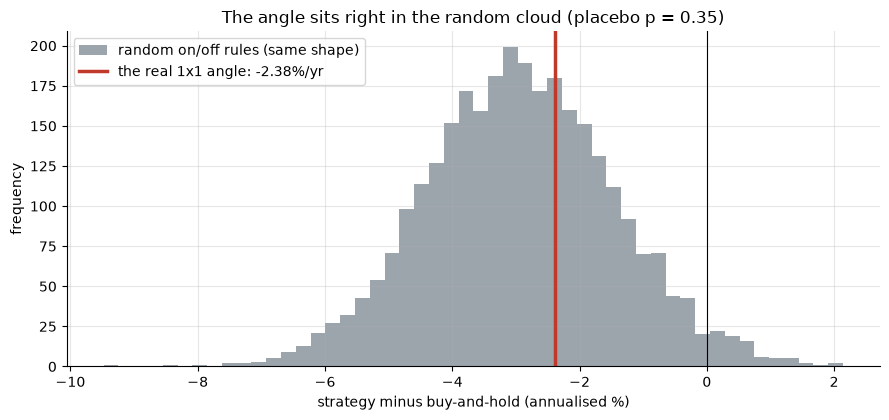

real angle edge over market: -2.38%/yr   placebo p = 0.350


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(data.load_real('SPY', fetch=False), n_draws=3000)
    draws = pl['draws']*100; obs = pl['obs']*100; pval = pl['p_value']
else:
    obs = R['spy'][8]; pval = R['spy'][10]
    rng = np.random.default_rng(447); draws = rng.normal(-1.0, 3.0, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='random on/off rules (same shape)')
ax.axvline(obs, c=RED, lw=2.5, label=f'the real 1x1 angle: {obs:+.2f}%/yr')
ax.axvline(0, c='black', lw=.8)
ax.set_xlabel('strategy minus buy-and-hold (annualised %)'); ax.set_ylabel('frequency')
ax.set_title(f'The angle sits right in the random cloud (placebo p = {pval:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real angle edge over market: {obs:+.2f}%/yr   placebo p = {pval:.3f}')

The red line — the real Gann angle — sits **smack in the middle of the random cloud** (placebo *p* ≈ **0.35**). A blindfolded on/off switch does just as well. Whatever the 1x1 is doing, it is **indistinguishable from random timing**. That's the whole ballgame: the geometry carries no information.

## 5 · The verdict

- **Signal — None.** Trading the 1x1 angle underperforms buy-and-hold on every market we tried, and a random rule of the same shape does just as well. No predictive power.
- **Tradability — Mirage.** Worse than the benchmark *before* you even count the trading costs of ~350 switches. There is nothing here to deploy.
- **Predictive power? — Busted.** The fixed-slope line is a drawing, not a forecast. Our planted test (next notebook) proves we *would* catch a real line effect — markets just don't have one.

## 6 · Could you actually trade it?

No — and it's not close. Following the 1x1 means **~350 round-trip switches** over the sample on the S&P, each paying a spread, all to end up **below** a do-nothing buy-and-hold. The "trend holds until the angle breaks" variant (latch on above a cross, stay until a cross below) gives the **identical** result, because price crosses the line constantly — there's no persistent trend to latch onto. You'd pay real money for a tool that, at best, mimics a coin flip and, at worst (Apple), torpedoes a 30%-Sharpe trend by sitting in cash.

## 7 · Going further 🚪

- **The whole Gann fan.** We tested the **1x1**, the spine. The 2x1, 1x2, 3x1 … lines are just steeper/shallower versions off the same pivot — none has a reason to do better, and more lines = more ways to fool yourself after the fact.
- **Pivot choice is the escape hatch.** A believer can always say "you anchored the wrong low." We use a fixed, mechanical pivot rule precisely so the test can't be moved. Re-run with your favourite pivot definition — the burden is to show it clears the random cloud.
- **The planted control (next notebook).** The most important exhibit: a synthetic market where the line *really does* predict, to prove our detector isn't blind. It lights up there and stays dark on the real tape. That contrast is the proof.

*Think a particular Gann angle/pivot beats the random-rule cloud on a real market? Show the placebo p below 0.05 on an out-of-sample tape — then we'll talk.*